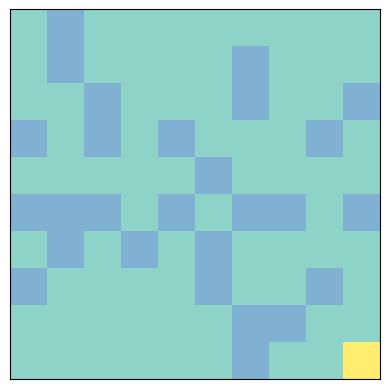

🎉 Congratulations! You reached the goal!


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from collections import deque
import time

# Maze settings
ROWS, COLS = 10, 10
maze = np.random.choice([0, 1], size=(ROWS, COLS), p=[0.7, 0.3])
maze[0, 0] = 0
maze[ROWS-1, COLS-1] = 0

# Player start
player_pos = [0, 0]
goal = [COLS-1, ROWS-1]

# Display function
def show_maze(maze, player_pos):
    clear_output(wait=True)
    display_maze = maze.copy()
    display_maze[player_pos[1], player_pos[0]] = 2  # Player
    display_maze[goal[1], goal[0]] = 3               # Goal
    plt.imshow(display_maze, cmap='Set3')
    plt.xticks([]); plt.yticks([])
    plt.show()

# BFS function to find shortest path from current player_pos
def bfs_shortest_path(maze, start, goal):
    queue = deque([start])
    visited = {tuple(start): None}
    directions = [(0,1),(1,0),(0,-1),(-1,0)]
    while queue:
        current = queue.popleft()
        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = visited[tuple(current)]
            path.reverse()
            return path
        for dx, dy in directions:
            nx, ny = current[0]+dx, current[1]+dy
            if 0 <= nx < COLS and 0 <= ny < ROWS and maze[ny, nx] == 0 and (nx, ny) not in visited:
                queue.append([nx, ny])
                visited[(nx, ny)] = current
    return None

# Movement mapping
moves = {'w': (0,-1), 's': (0,1), 'a': (-1,0), 'd': (1,0)}

# Game loop
show_maze(maze, player_pos)
while player_pos != goal:
    move = input("Move (w=up, s=down, a=left, d=right) or 'h' for AI hint: ").lower()
    
    if move == 'h':
        path = bfs_shortest_path(maze, player_pos, goal)
        if path:
            print(f"AI Hint: Next step -> {path[1]}")  # show next cell
        else:
            print("No path exists from current position!")
        continue
    
    if move in moves:
        dx, dy = moves[move]
        new_x = player_pos[0] + dx
        new_y = player_pos[1] + dy
        if 0 <= new_x < COLS and 0 <= new_y < ROWS and maze[new_y,new_x] == 0:
            player_pos = [new_x, new_y]
    show_maze(maze, player_pos)

print("🎉 Congratulations! You reached the goal!")